In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from torchvision.datasets import ImageFolder
from sklearn.decomposition import PCA

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from II_analyses.static_encoding import (
    compute_participation_ratio,
    compute_static_prediction_II,
    fit_static_projection,
)
from project_specific_utils.dataloader import (
    load_img_natraster,
    map_image_order_from_ann_to_monkey,
)
from useful_stuff.general_utils.regression import linear_encoding


In [2]:
@dataclass
class Cfg:
    # Neural recording and image-set parameters.
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    folder_name: str = "talia_20each_tizi"
    new_fs: int = 100
    neural_timepoint_idx: int = 17
    pca_comp = 100
    # Static model-feature parameters.
    model_name: str = "vit_l_16"
    img_size: int = 384
    layer_name: str = "blocks.1.mlp.fc2"
    pooling: str = "mean"

    # Linear encoding parameters. CV is deliberately disabled for this run.
    regression_type: str = "lr"
    use_cv: bool = False
    cv_type: str = "same"
    n_splits: int = 5
    shuffle: bool = True
    random_seed: int = 0
    alpha_min: float = 1e-6
    alpha_max: float = 1e3
    n_alphas: int = 10
    # Leading input-space SVD directions; None keeps each weight-matrix rank.
    n_neural_predictive_components: int | None = None
    n_model_predictive_components: int | None = None

    # Static Information Imbalance parameters.
    neural_RDM_metric: str = "cosine_cnt"
    model_RDM_metric: str = "cosine_cnt"
    k: int = 10
# EOC


cfg = Cfg()
cfg


Cfg(monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', new_fs=100, neural_timepoint_idx=17, model_name='vit_l_16', img_size=384, layer_name='blocks.1.mlp.fc2', pooling='mean', regression_type='lr', use_cv=False, cv_type='same', n_splits=5, shuffle=True, random_seed=0, alpha_min=1e-06, alpha_max=1000.0, n_alphas=10, n_neural_predictive_components=None, n_model_predictive_components=None, neural_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', k=10)

## Load and align the static spaces

The neural raster is shaped `(neurons, timepoints, images)`. Model features are reordered to the monkey image-presentation order and remain shaped `(model features, images)`.

In [3]:
raster = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)

dataset_path = Path(paths["livingstone_lab"]) / "Stimuli" / cfg.folder_name
dataset = ImageFolder(
    root=dataset_path,
    is_valid_file=lambda path: not path.endswith("Thumbs.db"),
    allow_empty=True,
)
idx_ord = map_image_order_from_ann_to_monkey(
    paths, cfg.monkey_name, cfg.date, dataset
)

features_path = (
    Path(paths["data_path"])
    / "models"
    / (
        f"{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{cfg.layer_name}"
        f"_features_{cfg.pooling}pool.npz"
    )
)
model_features = np.load(features_path)["arr_0"][:, idx_ord]
if cfg.pca_comp is not None:
    pca_obj = PCA(n_components=cfg.pca_comp)
    model_features = pca_obj.fit_transform(model_features.T)
    model_features = model_features.T

    
raster_array = raster.get_array()

if raster_array.ndim != 3:
    raise ValueError(
        "Expected neural data with shape (neurons, timepoints, images), "
        f"received {raster_array.shape}."
    )
# end if raster_array.ndim != 3
if model_features.ndim != 2:
    raise ValueError(
        "Expected model data with shape (features, images), "
        f"received {model_features.shape}."
    )
# end if model_features.ndim != 2
if raster_array.shape[2] != model_features.shape[1]:
    raise ValueError(
        "Neural and model spaces have different image counts: "
        f"{raster_array.shape[2]} and {model_features.shape[1]}."
    )
# end if raster_array.shape[2] != model_features.shape[1]

print(f"Neural raster: {raster_array.shape}")
print(f"Aligned model features: {model_features.shape}")
print(f"Model features loaded from: {features_path}")


Neural raster: (25, 30, 776)
Aligned model features: (100, 776)
Model features loaded from: /Users/tizianocausin/metrics_II_local/models/talia_20each_tizi_vit_l_16_384_blocks.1.mlp.fc2_features_meanpool.npz


In [4]:
n_timepoints = raster_array.shape[1]
if not -n_timepoints <= cfg.neural_timepoint_idx < n_timepoints:
    raise IndexError(
        f"neural_timepoint_idx={cfg.neural_timepoint_idx} is outside a response "
        f"with {n_timepoints} timepoints."
    )
# end if not -n_timepoints <= cfg.neural_timepoint_idx < n_timepoints

# Convert a possible negative index to the corresponding non-negative index.
timepoint_idx = cfg.neural_timepoint_idx % n_timepoints
neural_response = raster_array[:, timepoint_idx, :]
time_from_raster_start_s = timepoint_idx / raster.get_fs()

print(
    f"Selected neural timepoint {timepoint_idx}/{n_timepoints - 1} "
    f"({time_from_raster_start_s:.3f} s from raster start)."
)
print(f"Static neural response: {neural_response.shape}")


Selected neural timepoint 17/29 (0.170 s from raster start).
Static neural response: (25, 776)


## Fit the two static linear projections

`predicted_model` is generated from the neural response, while `predicted_neural` is generated from the model features. The default scores are descriptive in-sample $R^2$ values. With `cfg.use_cv=True`, the helper instead assembles predictions from held-out folds before computing $R^2$.

In [5]:
if cfg.regression_type not in {"lr", "ridge", "lasso", "en"}:
    raise ValueError(f"Unsupported regression_type: {cfg.regression_type}")
# end if cfg.regression_type not in supported types
if cfg.use_cv and cfg.cv_type not in {"loo", "kf"}:
    raise ValueError("Use 'loo' or 'kf' when use_cv=True.")
# end if cfg.use_cv and cfg.cv_type not in supported types

# The existing KFold implementation draws from NumPy's global random state.
alphas = np.logspace(
    np.log10(cfg.alpha_min), np.log10(cfg.alpha_max), cfg.n_alphas
)
active_cv_type = cfg.cv_type if cfg.use_cv else "same"

neural_to_model_encoding = linear_encoding(
    regression_type=cfg.regression_type,
    cv_type=active_cv_type,
    alphas=alphas,
    score_type="r2",
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
)
model_to_neural_encoding = linear_encoding(
    regression_type=cfg.regression_type,
    cv_type=active_cv_type,
    alphas=alphas,
    score_type="r2",
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
)

# Reset the seed before each direction so future CV uses identical folds.
np.random.seed(cfg.random_seed)
# neural -> model: each model feature is one regression target.
n_hat, model_r2 = fit_static_projection(
    neural_response,
    model_features,
    neural_to_model_encoding,
    use_cv=cfg.use_cv,
)

np.random.seed(cfg.random_seed)
# model -> neural: each neuron is one regression target.
m_hat, neural_r2 = fit_static_projection(
    model_features,
    neural_response,
    model_to_neural_encoding,
    use_cv=cfg.use_cv,
)


In [6]:
encoding_mode = "out-of-fold" if cfg.use_cv else "in-sample"
print(f"Encoding mode: {encoding_mode}")
print(
    "neural -> model: "
    f"mean R^2={np.nanmean(model_r2):.4f}, "
    f"median R^2={np.nanmedian(model_r2):.4f}, "
    f"prediction shape={n_hat.shape}"
)
print(
    "model -> neural: "
    f"mean R^2={np.nanmean(neural_r2):.4f}, "
    f"median R^2={np.nanmedian(neural_r2):.4f}, "
    f"prediction shape={m_hat.shape}"
)
print(
    "Full-data weight shapes: "
    f"neural -> model {neural_to_model_encoding.get_weights().shape}, "
    f"model -> neural {model_to_neural_encoding.get_weights().shape}"
)

# A high-dimensional in-sample projection can interpolate the neural targets.
if not cfg.use_cv and model_features.shape[0] >= model_features.shape[1]:
    print(
        "Note: model features outnumber images, so the in-sample model -> neural "
        "R² can be saturated. Enable CV for a generalization estimate."
    )
# end if not cfg.use_cv and model_features.shape[0] >= model_features.shape[1]


Encoding mode: in-sample
neural -> model: mean R^2=0.0399, median R^2=0.0373, prediction shape=(100, 776)
model -> neural: mean R^2=0.2122, median R^2=0.1939, prediction shape=(25, 776)
Full-data weight shapes: neural -> model (100, 25), model -> neural (25, 100)


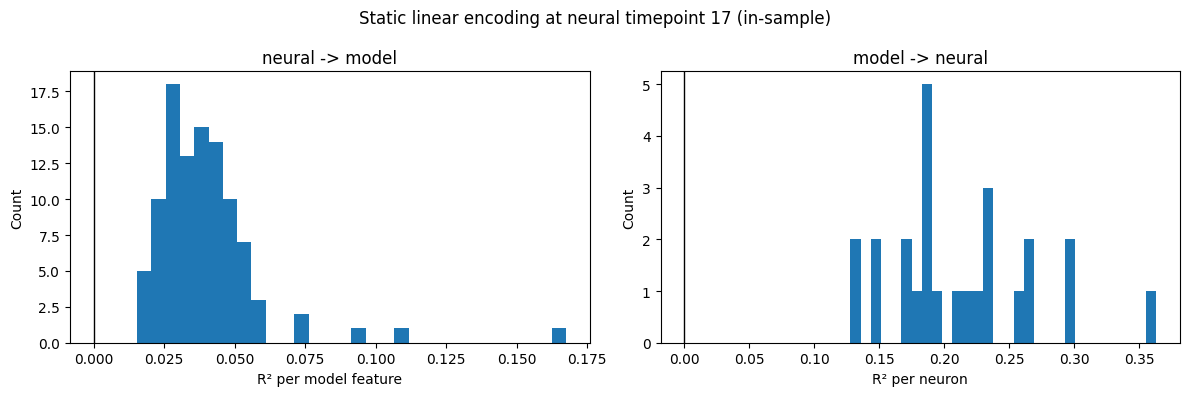

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(model_r2[np.isfinite(model_r2)], bins=30)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("neural -> model")
axes[0].set_xlabel("R² per model feature")
axes[0].set_ylabel("Count")

axes[1].hist(neural_r2[np.isfinite(neural_r2)], bins=30)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("model -> neural")
axes[1].set_xlabel("R² per neuron")
axes[1].set_ylabel("Count")

fig.suptitle(
    f"Static linear encoding at neural timepoint {timepoint_idx} ({encoding_mode})"
)
fig.tight_layout()


In [8]:
# Recover the neural x-subspace used by the fitted neural -> model map.
neural_to_model_weights = neural_to_model_encoding.get_weights()
_, neural_to_model_singular_values, neural_to_model_vh = np.linalg.svd(
    neural_to_model_weights,
    full_matrices=False,
)
neural_to_model_rank = np.linalg.matrix_rank(neural_to_model_weights)

# By default, retain only directions with non-zero predictive weight.
n_neural_predictive_components = (
    neural_to_model_rank
    if cfg.n_neural_predictive_components is None
    else cfg.n_neural_predictive_components
)
if not 1 <= n_neural_predictive_components <= neural_to_model_rank:
    raise ValueError(
        "n_neural_predictive_components must be between 1 and the neural -> model "
        f"weight rank ({neural_to_model_rank}); received "
        f"{n_neural_predictive_components}."
    )
# end if not 1 <= n_neural_predictive_components <= neural_to_model_rank

# Rows of Vh are orthonormal x directions, ordered by predictive singular value.
neural_predictive_basis = neural_to_model_vh[:n_neural_predictive_components]

# Apply only the orthonormal basis: singular values rank but do not scale x.
neural_predictive_response = neural_predictive_basis @ neural_response

print(f"Neural -> model weight rank: {neural_to_model_rank}")
print(f"Retained predictive basis: {neural_predictive_basis.shape}")
print(f"Transformed neural response: {neural_predictive_response.shape}")
print(
    "Retained singular values: "
    f"{neural_to_model_singular_values[:n_neural_predictive_components]}"
)

# Recover the model x-subspace used by the fitted model -> neural map.
model_to_neural_weights = model_to_neural_encoding.get_weights()
_, model_to_neural_singular_values, model_to_neural_vh = np.linalg.svd(
    model_to_neural_weights,
    full_matrices=False,
)
model_to_neural_rank = np.linalg.matrix_rank(model_to_neural_weights)

# By default, retain only directions with non-zero predictive weight.
n_model_predictive_components = (
    model_to_neural_rank
    if cfg.n_model_predictive_components is None
    else cfg.n_model_predictive_components
)
if not 1 <= n_model_predictive_components <= model_to_neural_rank:
    raise ValueError(
        "n_model_predictive_components must be between 1 and the model -> neural "
        f"weight rank ({model_to_neural_rank}); received "
        f"{n_model_predictive_components}."
    )
# end if not 1 <= n_model_predictive_components <= model_to_neural_rank

# These Vh rows are orthonormal directions in the original model-feature space.
model_predictive_basis = model_to_neural_vh[:n_model_predictive_components]

# Apply only the orthonormal basis: singular values rank but do not scale x.
model_predictive_response = model_predictive_basis @ model_features

print(f"Model -> neural weight rank: {model_to_neural_rank}")
print(f"Retained predictive basis: {model_predictive_basis.shape}")
print(f"Transformed model response: {model_predictive_response.shape}")
model_to_neural_singular_values[:n_model_predictive_components]


Neural -> model weight rank: 25
Retained predictive basis: (25, 25)
Transformed neural response: (25, 776)
Retained singular values: [1.09589275 0.37725915 0.26510773 0.23174775 0.21374681 0.19253831
 0.16295423 0.15024577 0.1382222  0.12604693 0.12491939 0.1129528
 0.09686828 0.08840364 0.08166378 0.07402018 0.07028571 0.06479939
 0.05581903 0.05496476 0.04662569 0.04493078 0.04097787 0.03675698
 0.03101917]
Model -> neural weight rank: 25
Retained predictive basis: (25, 100)
Transformed model response: (25, 776)


array([9.17931243, 6.4404904 , 5.25451148, 4.75565083, 4.41268384,
       4.1606856 , 3.88966554, 3.66186473, 3.59139029, 3.4144017 ,
       3.27892994, 3.16085831, 3.00366008, 2.90180034, 2.77812239,
       2.69240117, 2.45967479, 2.39356974, 2.21825412, 2.11850676,
       1.93036638, 1.88894243, 1.74903951, 1.57751986, 1.38074487])

## Participation ratio of the predictive subspaces

Participation ratio is computed from the eigenvalues of each centered projected-response covariance matrix. It measures the effective number of dimensions occupied by the images after the orthonormal SVD projection.

In [9]:
neural_predictive_participation_ratio = compute_participation_ratio(
    neural_predictive_response
)
model_predictive_participation_ratio = compute_participation_ratio(
    model_predictive_response
)

print(
    "Neural predictive-subspace participation ratio: "
    f"{neural_predictive_participation_ratio:.6f}"
)
print(
    "Model predictive-subspace participation ratio: "
    f"{model_predictive_participation_ratio:.6f}"
)


Neural predictive-subspace participation ratio: 14.608446
Model predictive-subspace participation ratio: 15.978163


## Information Imbalance between the predictive input subspaces

The neural and model responses are expressed in the leading right-singular-vector bases of their respective encoding weights. Therefore, static II `A2B` is **neural predictive subspace -> model predictive subspace**, and `B2A` is the reverse direction.

In [27]:
ii_obj, neural_subspace_to_model_subspace_II, model_subspace_to_neural_subspace_II = (
    compute_static_prediction_II(
        predicted_neural=neural_predictive_response,
        predicted_model=model_predictive_response,
        neural_RDM_metric=cfg.neural_RDM_metric,
        model_RDM_metric=cfg.model_RDM_metric,
        k=cfg.k,
    )
)

print(
    "neural predictive subspace -> model predictive subspace: "
    f"II={neural_subspace_to_model_subspace_II:.6f}"
)
print(
    "model predictive subspace -> neural predictive subspace: "
    f"II={model_subspace_to_neural_subspace_II:.6f}"
)


neural predictive subspace -> model predictive subspace: II=0.748423
model predictive subspace -> neural predictive subspace: II=0.735527


In [31]:

directions = ["neural subspace -> model", "model subspace -> neural"]
ii_values = [
    neural_subspace_to_model_subspace_II,
    model_subspace_to_neural_subspace_II,
]
print(directions[0], ii_values[0])
print(directions[1], ii_values[1])



neural subspace -> model 0.7484230523966415
model subspace -> neural 0.7355274869805505
